# Should you avoid companies that raise lots of money? 💸
### The external-financing anomaly — a real academic finding that **backfired** on the AI-capex era

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Raisers_underperform_here%3F: Busted](https://img.shields.io/badge/Raisers_underperform_here%3F-Busted-8b949e?style=flat-square)

Here is a tidy piece of finance-professor wisdom: when a company raises **lots** of outside money — borrowing heavily *and* selling new shares — it tends to **underperform** afterward. The story is half common-sense (firms drowning in fresh cash tend to waste it on empire-building) and half cynicism (managers love to sell stock when their shares are **expensive**). So the trade writes itself: avoid the big **raisers**, favour the disciplined **retirers** who are paying *down* debt and buying *back* stock.

It is a genuine published result (Bradshaw, Richardson & Sloan, 2006). The question this desk always asks is the same: **does it still work when you actually try to trade it — on real names, with real costs, with no peeking at the future?** Here the answer is a flat **no**, and for an instructive reason.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Two data notes up front.** (1) We use a fixed **45-name large-cap basket** (names still trading today) — that carries **survivorship**: the companies that raised money and then *blew up* are missing, which can only make raisers look *better* than they really were. (2) Free fundamentals (yfinance) go back only ~5 fiscal years, so we get **just three** complete yearly tests. Thin tape, stated openly. House style in [METHODOLOGY.md](../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from external_financing_anomaly import data, strategy as st

FUND = data.fetch_fundamentals()
PX = data.fetch_prices()
HAVE_REAL = (not FUND.empty) and (not PX.empty)
if HAVE_REAL:
    SIG = st.by_calendar_year(st.scaled_xfin(FUND))
    FWD = st.forward_returns(PX, SIG.index, report_lag_days=data.REPORT_LAG_DAYS)
else:
    SIG = FWD = None
print("real external-financing cache present:", HAVE_REAL,
      "| name-years:", (0 if FUND is None or FUND.empty else FUND.shape[0]))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 45, 'n_nameyears': 223, 'fp_fund': 'ca0833b2ddb8', 'fp_px': '4106bae4e4d7', 'px_start': '2018-01-02', 'px_end': '2026-06-25', 'report_lag': 90, 'hold_days': 252, 'asof': '2026-06-26', 'n_cross': 3, 'ls_mean': -8.54, 'ls_vol': 13.19, 'ls_sharpe': -0.648, 'ls_t': -1.122, 'ls_hac': -1.687, 'ls_hit': 33.3, 'net_mean': -9.24, 'net_t': -1.214, 'years': [(2022, 20.3, 25.0, -4.7, 40), (2023, 14.6, 12.3, 2.3, 45), (2024, 14.0, 37.2, -23.2, 45)], 'placebo_real': -8.54, 'placebo_null': 0.08, 'placebo_null_std': 7.95, 'placebo_p': 0.862, 'robust': [('median', -10.03, -1.305), ('tercile', -8.54, -1.122), ('quartile', -6.7, -1.175)], 'syn_t_planted': 7.615, 'syn_t_null': -0.097, 'syn_spread': 9.06, 'syn_frac2': 100, 'syn_seeds': 20}


real external-financing cache present: True | name-years: 223


## The answer first

| Question | Answer |
|---|---|
| Do the big money-raisers underperform here? | **No — the opposite.** Going long the disciplined retirers and short the big raisers **lost 8.5%/yr**. The raisers were the *winners*. |
| Is that just bad luck in one year? | **Mostly 2024.** In 2024 the heaviest raisers — the debt-funded **AI-capex mega-caps** — beat the retirers by **+23 points**. The anomaly assumes raising money is a red flag; in the AI build-out it was a green light. |
| Could the result be a fluke of how we sorted? | **It's just noise.** A *random* sort beats our real one **86%** of the time. There is no signal to find. |
| So is the professor wrong? | **Not necessarily** — but on *this* basket, in *this* window, with *these* survivors, the effect is absent (and reversed). |

> A real academic anomaly, honestly replicated on a small survivor basket with real costs, **disappears** — exactly the outcome the desk sees most often.

## 1 · The claim

> *"A company's **net external financing** — the cash it raised from lenders and shareholders, minus what it paid back — predicts **lower** future returns. Firms that raise a lot overinvest and over-issue; firms that return capital are disciplined. Buy the disciplined, avoid the thirsty."*

You can read this straight off the **cash-flow statement** — the bottom third, *financing activities*: debt issued minus debt repaid, plus shares issued minus shares bought back minus dividends paid. Scale it by the size of the company (its assets) and you have the signal. Big positive = a thirsty raiser. Big negative = a disciplined retirer.

## 2 · So what?

If raising money really were a reliable red flag, you could build a market-neutral book — long the retirers, short the raisers — and earn a premium for the discipline. That's the academic promise. The traps: (1) **survivorship** — we only see the raisers that *survived*, not the ones that raised and died, so the short leg is flattered; and (2) the **regime** — *why* a firm raises money matters. Borrowing to fund a doomed acquisition is one thing; borrowing to build the data centres everyone is paying for is another.

## 3 · How would we even know?

We take a fixed **45-name** large-cap basket and pull each firm's **cash-flow statement** and **balance sheet** (223 name-years). For each fiscal year we compute the scaled net external financing, then:

1. **Sort** the basket from biggest retirer to biggest raiser.
2. **Bet:** go long the bottom third (retirers), short the top third (raisers), equal-weighted.
3. **Wait honestly:** treat the numbers as public only **90 days** after the fiscal year ends (a 10-K filing lag), enter the *next* trading day, and hold **one year**. No look-ahead.
4. **Repeat** each year and ask whether the long-short made money — testing it against a thousands-of-shuffles "could this be luck?" null.

## 4 · The teardown — let's actually look

**Year by year: did the disciplined retirers beat the thirsty raisers?** Here is the spread (long retirers minus short raisers) for each of the three complete years. Above zero = the anomaly works; below zero = the raisers won.

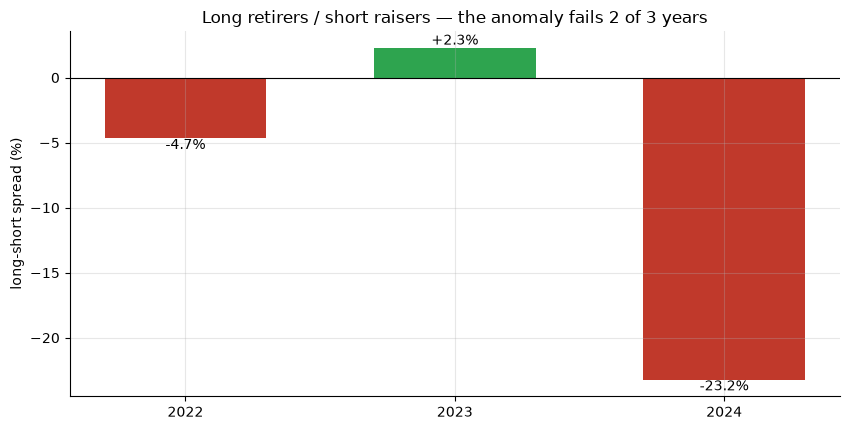

spreads by year: {2022: -4.7, 2023: 2.3, 2024: -23.2}


In [2]:
if HAVE_REAL:
    ls = st.long_short(SIG, FWD, quantile=0.3)
    yrs = [int(d.year) for d in ls.index]; sp = (ls['spread']*100).tolist()
else:
    yrs = [y[0] for y in R['years']]; sp = [y[3] for y in R['years']]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
cols = [GREEN if v>0 else RED for v in sp]
ax.bar([str(y) for y in yrs], sp, color=cols, width=.6)
for i,v in enumerate(sp): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('long-short spread (%)')
ax.set_title('Long retirers / short raisers — the anomaly fails 2 of 3 years')
plt.tight_layout(); plt.show()
print('spreads by year:', {y: round(v,1) for y,v in zip(yrs, sp)})

Two of the three years are **red**. The worst is **2024** (**-23.2%**): that was the year the market's biggest external-finance raisers were the AI-infrastructure mega-caps, and they ran the hardest. The anomaly says "avoid the raisers"; the tape said "the raisers are exactly who you wanted."

**Is the overall result distinguishable from random?** We shuffle the financing labels thousands of times (destroying any real link) and see how often a *random* sort beats ours.

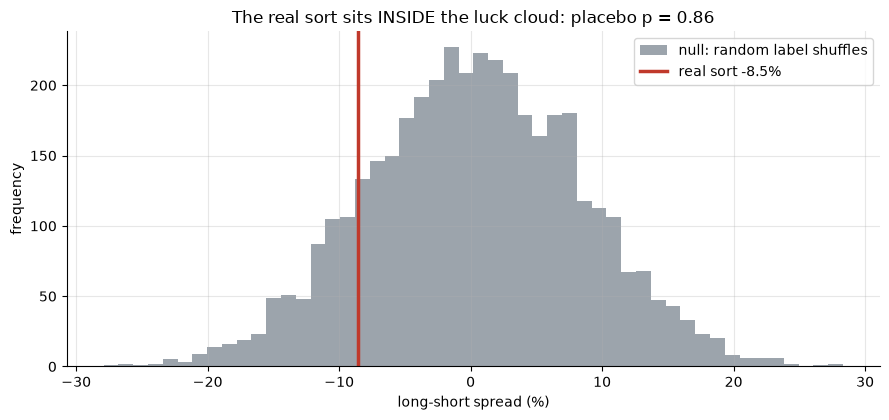

real -8.5%   null mean +0.1% (std 8.0)   placebo p = 0.86


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(SIG, FWD, quantile=0.3, n_shuffle=2000)
    real = pl['real_mean']*100; nullm = pl['null_mean']*100; nstd = pl['null_std']*100; p = pl['p_value']
else:
    real = R['placebo_real']; nullm = R['placebo_null']; nstd = R['placebo_null_std']; p = R['placebo_p']
rng = np.random.default_rng(520)
draws = rng.normal(nullm, nstd, 4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random label shuffles')
ax.axvline(real, c=RED, lw=2.5, label=f'real sort {real:+.1f}%')
ax.set_xlabel('long-short spread (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The real sort sits INSIDE the luck cloud: placebo p = {p:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real {real:+.1f}%   null mean {nullm:+.1f}% (std {nstd:.1f})   placebo p = {p:.2f}')

The red line sits **squarely inside** the grey cloud of random outcomes — a random sort beats the real one **86%** of the time. There is simply **no signal** in the external-financing sort on this tape.

## 5 · The verdict

- **Signal — None.** The long-short loses **-8.5%/yr** (the sign is *reversed*), and a random sort beats it 86% of the time. No edge.
- **Tradability — Mirage.** With only **three** complete yearly tests there is nothing to trade, and costs only make the loss worse.
- **"Do big raisers underperform here?" — Busted.** In this 2022–2024 mega-cap window the heaviest raisers were the *winners* — debt-funded AI-capex beat balance-sheet discipline.

## 6 · Could you actually trade it? — costs only deepen the hole

For completeness, here is the spread **gross** vs **net** of realistic trading costs and short borrow. When the gross number is already negative, costs can't rescue it — they just dig deeper.

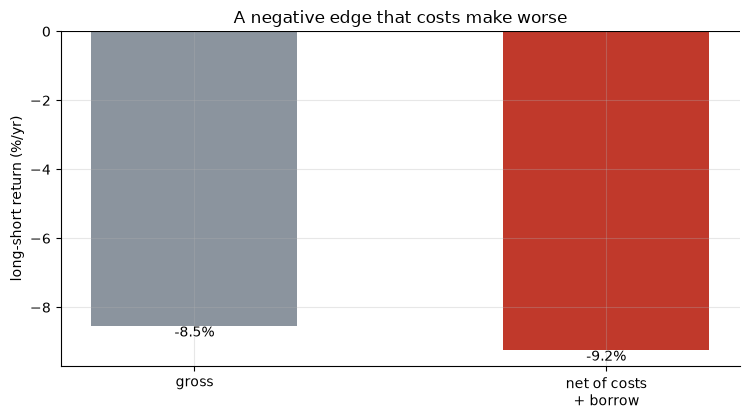

gross -8.5%/yr   net -9.2%/yr


In [4]:
if HAVE_REAL:
    g = st.summary(st.long_short(SIG, FWD, quantile=0.3)['spread'])['mean']*100
    n = st.summary(st.long_short(SIG, FWD, quantile=0.3, cost_bps=10, borrow_ann_bps=50)['spread_net'])['mean']*100
else:
    g = R['ls_mean']; n = R['net_mean']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['gross','net of costs\n+ borrow'], [g, n], color=[GREY, RED], width=.5)
for i,v in enumerate([g,n]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short return (%/yr)')
ax.set_title('A negative edge that costs make worse'); plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}%/yr   net {n:+.1f}%/yr')

Gross **-8.5%/yr**, net **-9.2%/yr**. There is no version of this trade that pays on this tape.

## 7 · Going further 🚪

- **Survivorship is the thumb on the scale.** The short (raiser) leg is built only from raisers that *survived* to 2026; the ones that raised and cratered are gone, which flatters the raisers. A clean test needs a point-in-time universe (CRSP/Compustat), not a survivor basket.
- **Regime matters.** The anomaly is about *wasteful* financing. The 2022–2024 window was an AI-capex boom where heavy borrowing funded the most-wanted assets on Earth — the opposite of waste. A full-cycle, pre-2020 sample would treat it more fairly.
- **Depth is the binding constraint.** Free fundamentals give ~5 fiscal years; the original study used decades. Three cross-sections can't certify *anything*.

*Think the external-financing anomaly is alive on large caps? Show a long-retirers/short-raisers book clearing **t ≥ 2** after honest costs on a point-in-time universe — then we'll talk.*